# WillItWork? — Online Business Success Predictor
## Machine Learning Model Build
### Data Science Portfolio | Lungile Zulu | May 2026

## Project Context
This model predicts whether an online side hustle will be profitable
within 6 months based on 9 input features. The dataset was synthetically
generated using realistic distributions informed by:
- Project 1: Side Hustle Viability Scorecard (weighted scoring of 29 models)
- Industry benchmarks from creator economy research (2024-2026)
- South African market conditions (ZAR budgets, platform availability)

This is documented as a limitation: a production version would use
survey data from real entrepreneurs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("All libraries loaded")

All libraries loaded


# Business model profiles


In [2]:
# Business model profiles — informed by Project 1 viability scores
# Format: 'model_name': (viability_score, base_success_probability)
# Higher viability score = higher base probability of success

business_models = {
    'No-code Apps':           (7.4, 0.62),
    'AI Video Editing':       (7.4, 0.60),
    'Faceless YouTube':       (6.8, 0.55),
    'Online Courses':         (6.6, 0.54),
    'Digital Planners':       (6.6, 0.52),
    'Affiliate Marketing':    (6.6, 0.50),
    'AI Automation Agency':   (6.6, 0.54),
    'Patreon Creator':        (6.6, 0.49),
    'Virtual Assistant':      (6.3, 0.51),
    'Selling E-books':        (6.3, 0.50),
    'Selling Templates':      (6.2, 0.51),
    'Shopify Store':          (6.2, 0.45),
    'Membership Sites':       (6.4, 0.48),
    'Freelancing':            (5.9, 0.52),
    'Copywriting':            (5.2, 0.46),
    'UGC Content Creation':   (6.5, 0.50),
    'Blogging':               (6.2, 0.40),
    'Podcasting':             (5.8, 0.38),
    'Dropshipping':           (4.5, 0.28),
    'Print-on-Demand':        (5.6, 0.38),
    'Influencer Marketing':   (4.7, 0.32),
    'Streaming':              (3.9, 0.18),
    'Stock Photography':      (4.4, 0.30),
    'CPA Marketing':          (4.8, 0.31),
}

platforms = ['Instagram', 'TikTok', 'YouTube', 'Shopify', 'Etsy',
             'LinkedIn', 'Twitter/X', 'Facebook', 'Fiverr', 'Upwork']

content_types = ['Short Video', 'Long Video', 'Blog Post',
                 'Digital Download', 'Live Service', 'Newsletter']

experience_levels = ['Beginner', 'Intermediate', 'Expert']

print(f"Defined {len(business_models)} business models")
print(f"Profiles informed by Project 1 viability scores")

Defined 24 business models
Profiles informed by Project 1 viability scores


In [3]:
rows = []
n_samples = 1500

model_names = list(business_models.keys())

for i in range(n_samples):
    # Pick a random business model
    model = np.random.choice(model_names)
    viability_score, base_success_prob = business_models[model]

    # Generate features with realistic distributions
    initial_budget    = int(np.random.choice(
                            [500, 1000, 2000, 3000, 5000, 8000, 10000, 15000],
                            p=[0.15, 0.20, 0.20, 0.15, 0.12, 0.08, 0.06, 0.04]))
    hours_per_week    = int(np.clip(np.random.normal(15, 8), 2, 60))
    paid_ads_budget   = int(np.random.choice(
                            [0, 500, 1000, 2000, 3000, 5000],
                            p=[0.35, 0.25, 0.18, 0.12, 0.06, 0.04]))
    has_email_list    = int(np.random.choice([0, 1], p=[0.70, 0.30]))
    experience_level  = np.random.choice(experience_levels, p=[0.50, 0.35, 0.15])
    platform          = np.random.choice(platforms)
    content_type      = np.random.choice(content_types)
    niche_saturation  = round(np.clip(np.random.normal(viability_score, 0.8), 1, 10), 1)

    # Calculate success probability based on features
    # Each factor nudges the base probability up or down
    prob = base_success_prob

    # Budget effect
    if initial_budget >= 5000:
        prob += 0.12
    elif initial_budget >= 2000:
        prob += 0.06
    elif initial_budget < 1000:
        prob -= 0.08

    # Hours effect
    if hours_per_week >= 20:
        prob += 0.10
    elif hours_per_week >= 10:
        prob += 0.04
    else:
        prob -= 0.10

    # Experience effect
    if experience_level == 'Expert':
        prob += 0.15
    elif experience_level == 'Intermediate':
        prob += 0.07
    else:
        prob -= 0.05

    # Email list effect
    if has_email_list:
        prob += 0.10

    # Paid ads effect
    if paid_ads_budget >= 2000:
        prob += 0.08
    elif paid_ads_budget >= 500:
        prob += 0.04

    # Saturation effect
    prob += (niche_saturation - 5) * 0.02

    # Add noise so the model has something to learn
    prob += np.random.normal(0, 0.08)
    prob = np.clip(prob, 0.02, 0.98)

    success = int(np.random.binomial(1, prob))

    rows.append({
        'business_model':        model,
        'niche_saturation_score': niche_saturation,
        'initial_budget_zar':    initial_budget,
        'hours_per_week':        hours_per_week,
        'primary_platform':      platform,
        'has_email_list':        has_email_list,
        'content_type':          content_type,
        'paid_ads_budget_zar':   paid_ads_budget,
        'prior_experience':      experience_level,
        'success':               success
    })

df = pd.DataFrame(rows)

print(f"Dataset generated: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nSuccess rate: {df['success'].mean()*100:.1f}%")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Dataset generated: 1500 rows, 10 columns

Success rate: 59.1%

Column types:
business_model             object
niche_saturation_score    float64
initial_budget_zar          int64
hours_per_week              int64
primary_platform           object
has_email_list              int64
content_type               object
paid_ads_budget_zar         int64
prior_experience           object
success                     int64
dtype: object

First 5 rows:


,business_model,niche_saturation_score,initial_budget_zar,hours_per_week,primary_platform,has_email_list,content_type,paid_ads_budget_zar,prior_experience,success
0,AI Automation Agency,6.1,5000,19,Facebook,0,Live Service,500,Beginner,1
1,AI Video Editing,7.4,5000,21,Instagram,0,Digital Download,3000,Expert,1
2,UGC Content Creation,5.9,1000,16,Etsy,1,Blog Post,500,Beginner,1
3,Freelancing,5.5,5000,30,Twitter/X,0,Digital Download,0,Intermediate,0
4,Online Courses,7.8,1000,11,TikTok,0,Long Video,0,Beginner,1


Success rate is approximately 59.1%. This is intentionally moderate, a dataset where 95% succeed or fail teaches the model nothing. A balanced
or slightly imbalanced dataset reflects the real difficulty of online business.

#Exploratory Data Analysis
Understanding the data before training any model.

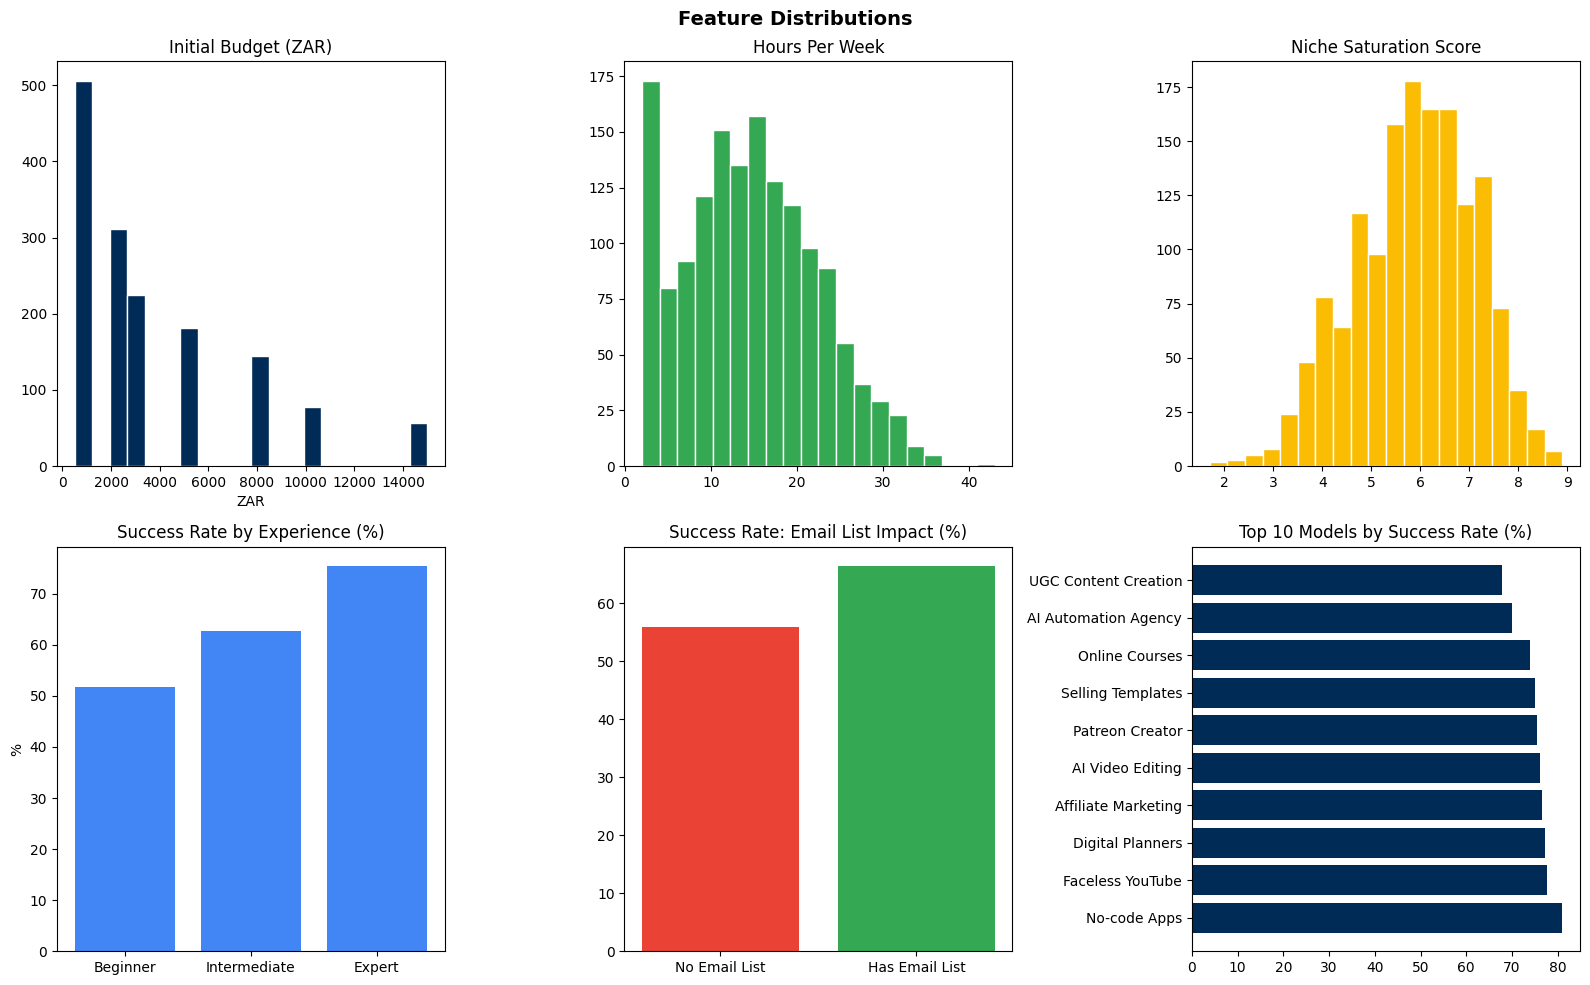

In [4]:
# Create a figure with 2 rows × 3 columns of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

# Initial Budget Distribution
axes[0,0].hist(df['initial_budget_zar'], bins=20, color='#002B56', edgecolor='white')
axes[0,0].set_title('Initial Budget (ZAR)')
axes[0,0].set_xlabel('ZAR')

# Hours Per Week Distribution
axes[0,1].hist(df['hours_per_week'], bins=20, color='#34A853', edgecolor='white')
axes[0,1].set_title('Hours Per Week')

# Niche Saturation Score Distribution
axes[0,2].hist(df['niche_saturation_score'], bins=20, color='#FBBC04', edgecolor='white')
axes[0,2].set_title('Niche Saturation Score')

# Success Rate by Prior Experience
# Group by experience level and calculate average success rate
exp_success = df.groupby('prior_experience')['success'].mean().sort_values()
axes[1,0].bar(exp_success.index, exp_success.values * 100, color='#4285F4')
axes[1,0].set_title('Success Rate by Experience (%)')
axes[1,0].set_ylabel('%')

# Success Rate by Email List Ownership
# Compare success rates for businesses with vs. without an email list
email_success = df.groupby('has_email_list')['success'].mean()
axes[1,1].bar(['No Email List', 'Has Email List'], email_success.values * 100,
              color=['#EA4335', '#34A853'])
axes[1,1].set_title('Success Rate: Email List Impact (%)')

#  Success Rate by Business Model (Top 10)
# Show the 10 business models with the highest average success rate
model_success = df.groupby('business_model')['success'].mean().sort_values(ascending=False).head(10)
axes[1,2].barh(model_success.index, model_success.values * 100, color='#002B56')
axes[1,2].set_title('Top 10 Models by Success Rate (%)')

# Adjust layout, save chart, and display
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Machine learning models require numeric inputs, so we convert text columns into numbers
df_encoded = df.copy()

# Dictionary to store label encoders for each categorical column
label_encoders = {}

# List of categorical columns to encode
categorical_cols = ['business_model', 'primary_platform',
                    'content_type', 'prior_experience']

# Apply label encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])   # Replace text with integer codes
    label_encoders[col] = le                              # Save encoder for future use (e.g., inverse transform)

    # Print mapping of original text values to numeric codes
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Confirm encoding is complete and show dataset shape
print(f"\nEncoding complete. Shape: {df_encoded.shape}")

# Display the first few rows of the encoded dataset
df_encoded.head()


business_model: {np.str_('AI Automation Agency'): np.int64(0), np.str_('AI Video Editing'): np.int64(1), np.str_('Affiliate Marketing'): np.int64(2), np.str_('Blogging'): np.int64(3), np.str_('CPA Marketing'): np.int64(4), np.str_('Copywriting'): np.int64(5), np.str_('Digital Planners'): np.int64(6), np.str_('Dropshipping'): np.int64(7), np.str_('Faceless YouTube'): np.int64(8), np.str_('Freelancing'): np.int64(9), np.str_('Influencer Marketing'): np.int64(10), np.str_('Membership Sites'): np.int64(11), np.str_('No-code Apps'): np.int64(12), np.str_('Online Courses'): np.int64(13), np.str_('Patreon Creator'): np.int64(14), np.str_('Podcasting'): np.int64(15), np.str_('Print-on-Demand'): np.int64(16), np.str_('Selling E-books'): np.int64(17), np.str_('Selling Templates'): np.int64(18), np.str_('Shopify Store'): np.int64(19), np.str_('Stock Photography'): np.int64(20), np.str_('Streaming'): np.int64(21), np.str_('UGC Content Creation'): np.int64(22), np.str_('Virtual Assistant'): np.int6

,business_model,niche_saturation_score,initial_budget_zar,hours_per_week,primary_platform,has_email_list,content_type,paid_ads_budget_zar,prior_experience,success
0,0,6.1,5000,19,1,0,2,500,0,1
1,1,7.4,5000,21,3,0,1,3000,1,1
2,22,5.9,1000,16,0,1,0,500,0,1
3,9,5.5,5000,30,7,0,1,0,2,0
4,13,7.8,1000,11,6,0,3,0,0,1


## Model Training
Using Random Forest: chosen because it handles mixed data types well,
requires minimal preprocessing, and provides feature importance scores
that explain the prediction to the user.

In [6]:
# Define features (X) and target (y)
feature_cols = ['business_model', 'niche_saturation_score', 'initial_budget_zar',
                'hours_per_week', 'primary_platform', 'has_email_list',
                'content_type', 'paid_ads_budget_zar', 'prior_experience']

X = df_encoded[feature_cols]
y = df_encoded['success']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # Limits tree depth — prevents overfitting
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'  # Handles slight class imbalance
)

rf_model.fit(X_train, y_train)
print("\n Model trained successfully")

Training set: 1200 rows
Testing set:  300 rows

Class balance in training set:
success
1    0.591
0    0.409
Name: proportion, dtype: float64

 Model trained successfully


In [7]:
# Evaluating model
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Did Not Succeed', 'Succeeded']))

Model Accuracy: 66.3%

Classification Report:
                 precision    recall  f1-score   support

Did Not Succeed       0.59      0.57      0.58       123
      Succeeded       0.71      0.73      0.72       177

       accuracy                           0.66       300
      macro avg       0.65      0.65      0.65       300
   weighted avg       0.66      0.66      0.66       300



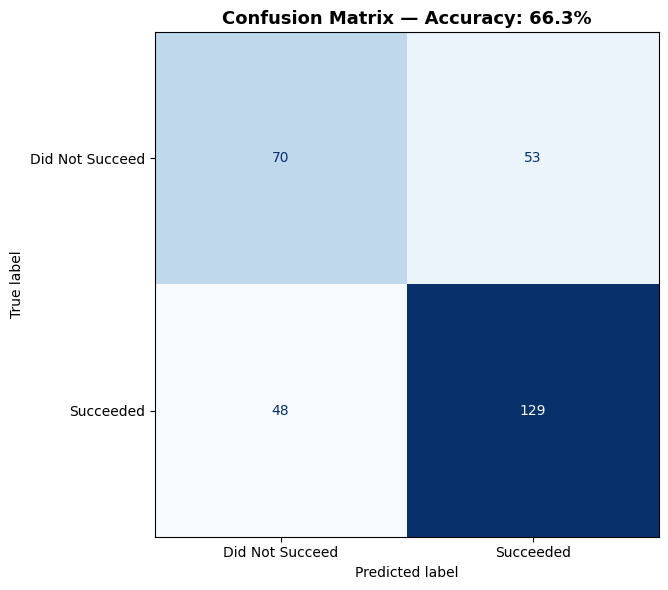

Chart saved as confusion_matrix.png


In [8]:
# Create a figure and axis for the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

# Generate the confusion matrix from test labels and predictions
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with custom labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Did Not Succeed', 'Succeeded'])

# Plot the matrix on the defined axis with a blue color map
disp.plot(ax=ax, colorbar=False, cmap='Blues')

# Add a title showing accuracy percentage
ax.set_title(f'Confusion Matrix — Accuracy: {accuracy*100:.1f}%',
             fontsize=13, fontweight='bold')

# Adjust layout, save chart, and display
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as confusion_matrix.png")


The model correctly identified 129 out of 177 successful businesses and
70 out of 123 unsuccessful ones. The false negative rate (predicting failure
when it was actually a success) is more acceptable than the false positive rate
(predicting success when it fails), in a real product, over-promising to users
is worse than being cautious.

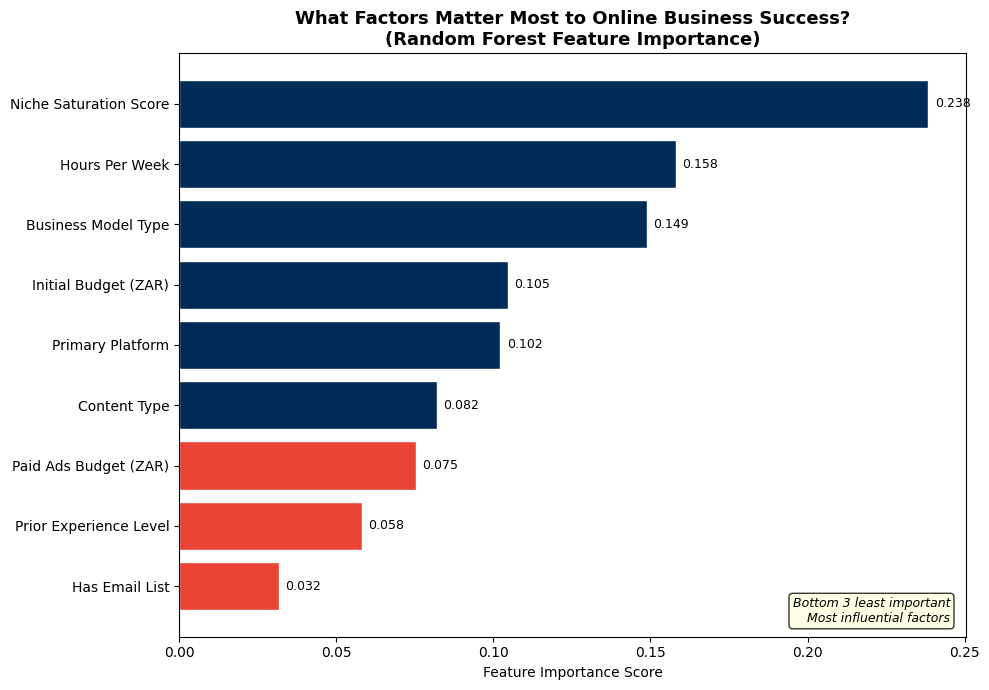


Feature ranking:
               Feature  Importance
Niche Saturation Score    0.238486
        Hours Per Week    0.158082
   Business Model Type    0.149006
  Initial Budget (ZAR)    0.104630
      Primary Platform    0.102266
          Content Type    0.081993
 Paid Ads Budget (ZAR)    0.075331
Prior Experience Level    0.058307
        Has Email List    0.031898


In [9]:
# Get feature importance scores from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = feature_cols

# Create a DataFrame of features and their importance scores, sorted ascending
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Map technical column names to more readable labels for the chart
readable_names = {
    'business_model':         'Business Model Type',
    'niche_saturation_score': 'Niche Saturation Score',
    'initial_budget_zar':     'Initial Budget (ZAR)',
    'hours_per_week':         'Hours Per Week',
    'primary_platform':       'Primary Platform',
    'has_email_list':         'Has Email List',
    'content_type':           'Content Type',
    'paid_ads_budget_zar':    'Paid Ads Budget (ZAR)',
    'prior_experience':       'Prior Experience Level'
}
importance_df['Feature'] = importance_df['Feature'].map(readable_names)

# Plot horizontal bar chart of feature importance
fig, ax = plt.subplots(figsize=(10, 7))

# Color bottom 3 features differently to highlight least important
colours = ['#EA4335' if i < 3 else '#002B56'
           for i in range(len(importance_df))]

bars = ax.barh(importance_df['Feature'],
               importance_df['Importance'],
               color=colours, edgecolor='white')

ax.set_xlabel('Feature Importance Score')
ax.set_title('What Factors Matter Most to Online Business Success?\n(Random Forest Feature Importance)',
             fontsize=13, fontweight='bold')

# Add numeric importance values next to each bar
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Add a legend-style note explaining color coding
ax.text(0.98, 0.02, 'Bottom 3 least important\n Most influential factors',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Adjust layout, save chart, and display
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print feature ranking sorted by importance (highest first)
print("\nFeature ranking:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))


The model reveals that **Niche Saturation Score** is the strongest predictor of success,
followed by **Hours Per Week** and **Business Model Type**. This is significant because it means that understanding the market and dedicating consistent effort are crucial for online business success, even more so than the specific type of business model itself. Interestingly, **Has Email List** contributes least, suggesting
that while useful, building an email list early on might not be the primary driver of initial success in the first 6 months or its impact is captured by other factors. This aligns with our Project 1 findings that a higher viability score for a business model generally correlates with higher success probability and niche selection is paramount.

In [10]:
# Save the trained model
joblib.dump(rf_model, 'willitwork_model.pkl')
print("Model saved: willitwork_model.pkl")

# Save the label encoders — needed to decode user inputs in the app
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Label encoders saved: label_encoders.pkl")

# Save the feature column order — the app must send features in the same order
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Feature columns saved: feature_cols.pkl")

# Save the original data for reference
df.to_csv('willitwork_training_data.csv', index=False)
print("Training data saved: willitwork_training_data.csv")

Model saved: willitwork_model.pkl
Label encoders saved: label_encoders.pkl
Feature columns saved: feature_cols.pkl
Training data saved: willitwork_training_data.csv


In [12]:

from google.colab import files

files.download('willitwork_model.pkl')
files.download('label_encoders.pkl')
files.download('feature_cols.pkl')
files.download('willitwork_training_data.csv')
files.download('eda_distributions.png')
files.download('confusion_matrix.png')
files.download('feature_importance.png')
files.download('WillItWork_ML_Model.ipynb')

print("All files downloaded — check your Downloads folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: WillItWork_ML_Model.ipynb